# Project: Advanced Machine Learning - Easy Visa

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.


## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description
The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
has_job_experience: Does the employee has any job experience? Y= Yes; N = No
requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
yr_of_estab: Year in which the employer's company was established
region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position
* case_status: Flag indicating if the Visa was certified or denied


## Key Goals Or Problems to be solved:

* Analyze the data of large number of Visa applicants.
* Facilitate the process of visa approvals, by helping in shortlisting the candidates having higher chances of VISA approval.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.


### Importing the required libraries

In [2]:
#Installing the libraries with specific versions
!pip install pandas==2.2.2 numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 xgboost==2.1.4 imbalanced-learn==0.13.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 7.8 MB/s eta 0:00:00


In [79]:
# To help with reading and manipulation of data
import numpy as np
from numpy import array
import pandas as pd

# To help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To split the data
from sklearn.model_selection import train_test_split

# To impute missing values
from sklearn.impute import SimpleImputer

# To do one-hot encoding
from sklearn.preprocessing import OneHotEncoder

# To build different classification and ensemble models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# To get different performance metrics
import sklearn.metrics as metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    accuracy_score,
    precision_score,
    f1_score,
)
from sklearn.model_selection import RandomizedSearchCV

# To undersample and oversample the data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# To suppress warnings
import warnings
warnings.filterwarnings("ignore")

## Data Overview

### Loading the Data and Reviewing it

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# loading data into a dataframe
path='/content/drive/MyDrive/Learnings//Python_Saved_Path/EasyVisa.csv'
easy_visa_data=pd.read_csv(path)

# creating a copy of the data
data=easy_visa_data.copy()

In [6]:
#reading the data
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [7]:
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


In [8]:
data.sample(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
21386,EZYV21387,Asia,Bachelor's,Y,N,2987,2001,Northeast,120369.48,Year,N,Certified
13613,EZYV13614,Asia,Bachelor's,Y,N,2247,1989,South,25071.66,Year,Y,Certified
4440,EZYV4441,Asia,Master's,N,Y,2948,1873,South,52812.07,Year,Y,Denied
21720,EZYV21721,Africa,Master's,Y,N,717,2003,Northeast,57194.88,Year,Y,Certified
12376,EZYV12377,Asia,Master's,Y,N,5778,1925,Northeast,97860.95,Year,Y,Certified


In [9]:
data.shape

(25480, 12)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [11]:
# Getting the statistical summary of the data
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Fetching the count of records with negative values of no. of employees
data[data['no_of_employees']<0]['case_id'].count()


np.int64(33)

### Observations

* There are 25480 rows and 12 columns in the dataset.
* There are 2 integer columns (No. of Employees and Year of Establishment), 1 Decimal column (Prevailing Wage), and all other columns are Object type.
* A few of the columns seem like they could be converted to categorical type, since they have small no. of unique values.
* The no. of employees column has a minimum of -26, which seems irrational.
* The year of establishment starts at 1800, which looks unexpected.

Next Steps:
1. Considering the no. of employees cannot be negative, and since there are only 33 of such records out of 25480, we can assume that this was a data collection mistake and we'll take the absolute value of this column.
2. The year of establishment starts at 1800, which should be checked with the people responsible for providing the data to ensure it is correct.


In [13]:
# Replacing the no of employees column with absolute values of the data
data['no_of_employees']=data['no_of_employees'].abs()
data['no_of_employees'].describe()

,no_of_employees
count,25480.000000
mean,5667.089207
std,22877.917453
min,11.000000
25%,1022.000000
50%,2109.000000
75%,3504.000000
max,602069.000000


In [14]:
# Checking for the unique values in categorical columns
categorical=['continent','education_of_employee','has_job_experience','requires_job_training','region_of_employment','unit_of_wage','full_time_position','case_status']
for i in categorical:
  print('-'*50)
  print(data[i].value_counts())
  print('-'*50)
  print('\n')


--------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------


--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------


--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------


--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------


--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      43

### Observations
* Case_Id is the unique ID of each Visa application and hence is not categorical in nature. It can be dropped after the duplicate check.
* Continents column is categorical - with 6 unique values of no particular order
* Education_of_employee is categorical - with 4 unique values which are ordinal in nature
* has_job_experience, requires_job_training, full_time_position and case_status are categorical with 2 unique values each
* region_of_employment is categorical - with 4 unique values which are not ordinal in nature
* unit_of_wage is categorical - with 4 unique values which are ordinal in nature

Next Steps:
1. Converting all the relevant columns into categorical cols.
2. The encoding of the columns would be done after the EDA is completed.

In [15]:
categorical

['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [16]:
# Converting relevant Object variables into Categorical variables
for i in categorical:
  data[i]=data[i].astype('category')

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   case_id                25480 non-null  object  
 1   continent              25480 non-null  category
 2   education_of_employee  25480 non-null  category
 3   has_job_experience     25480 non-null  category
 4   requires_job_training  25480 non-null  category
 5   no_of_employees        25480 non-null  int64   
 6   yr_of_estab            25480 non-null  int64   
 7   region_of_employment   25480 non-null  category
 8   prevailing_wage        25480 non-null  float64 
 9   unit_of_wage           25480 non-null  category
 10  full_time_position     25480 non-null  category
 11  case_status            25480 non-null  category
dtypes: category(8), float64(1), int64(2), object(1)
memory usage: 996.7+ KB


### Checking the Data for Missing Data and Duplicates

In [17]:
# Getting the statistical summary of the data
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.089207,22877.917453,11.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# Checking the data for missing values
data.isna().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


In [19]:
data.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


In [20]:
data.duplicated().sum()

np.int64(0)

### Observations
* There are no missing values or duplicate records

Next Steps:
The Case_Id column can be dropped since it is of value to the analysis

In [21]:
# Case_id is unique for each applicant and might not add value to the rest of the analysis
data.drop(["case_id"], axis=1, inplace=True)

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25480 non-null  category
 1   education_of_employee  25480 non-null  category
 2   has_job_experience     25480 non-null  category
 3   requires_job_training  25480 non-null  category
 4   no_of_employees        25480 non-null  int64   
 5   yr_of_estab            25480 non-null  int64   
 6   region_of_employment   25480 non-null  category
 7   prevailing_wage        25480 non-null  float64 
 8   unit_of_wage           25480 non-null  category
 9   full_time_position     25480 non-null  category
 10  case_status            25480 non-null  category
dtypes: category(8), float64(1), int64(2)
memory usage: 797.7 KB


## Exploratory Data Analysis

### Univariate Analysis

In [23]:
# Beginning the Analysis by clearly identifying the numerical and categorical columns
num_cols = data.select_dtypes(include=np.number).columns.tolist()
cat_cols = data.select_dtypes(include="category").columns.tolist()
print(f"Numerical Columns: {num_cols}")
print(f"Categorical Columns: {cat_cols}")

Numerical Columns: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
Categorical Columns: ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


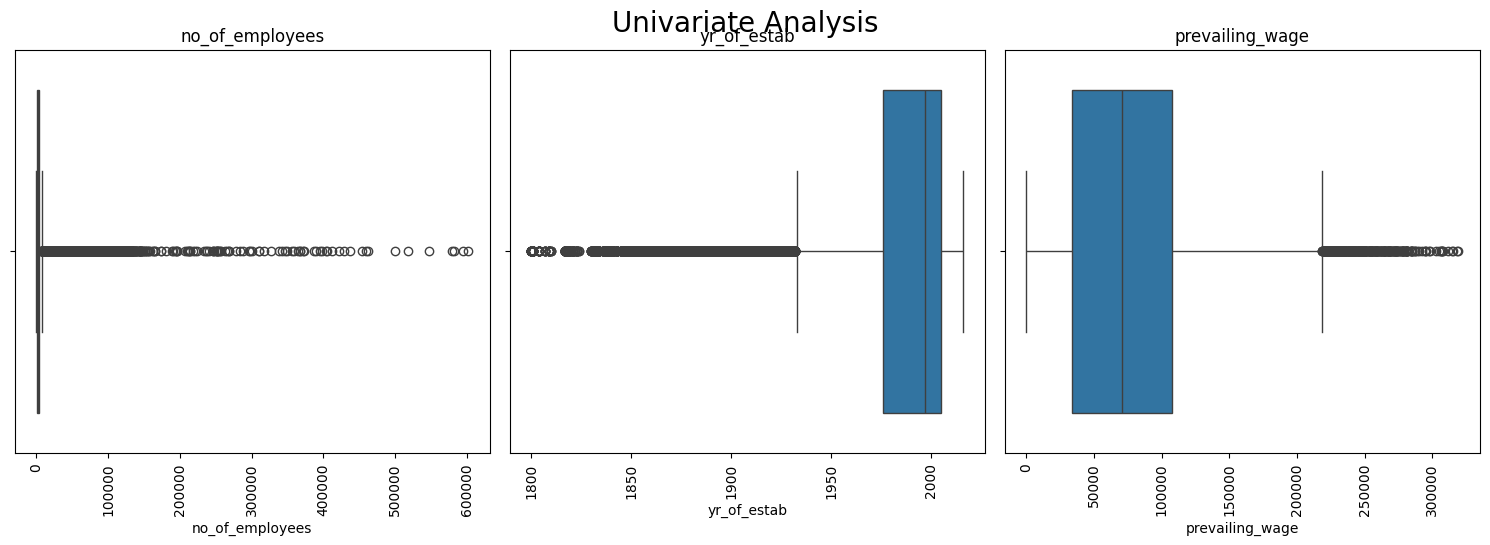

In [24]:
# Getting all the column names in a variable
col_names=data.columns.to_list()
col_names.remove('case_status')
col_names

plt.figure(figsize=(15,20))
plt.suptitle('Univariate Analysis',fontsize=20)
for i, feature in enumerate(num_cols):
    plt.subplot(4,3,i+1)
    sns.boxplot(data,x=feature)
    plt.title(feature)
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

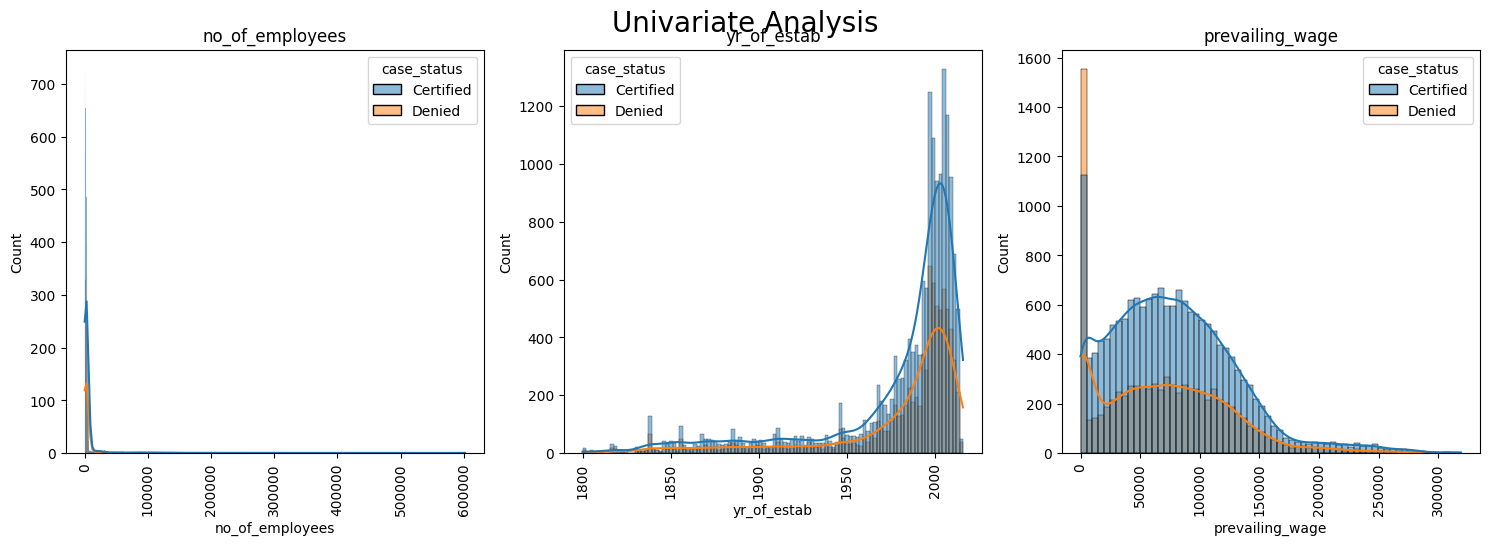

In [25]:
plt.figure(figsize=(15,20))
plt.suptitle('Univariate Analysis',fontsize=20)
for i, feature in enumerate(num_cols):
    plt.subplot(4,3,i+1)
    sns.histplot(data,x=feature,hue='case_status', kde=True)
    plt.title(feature)
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

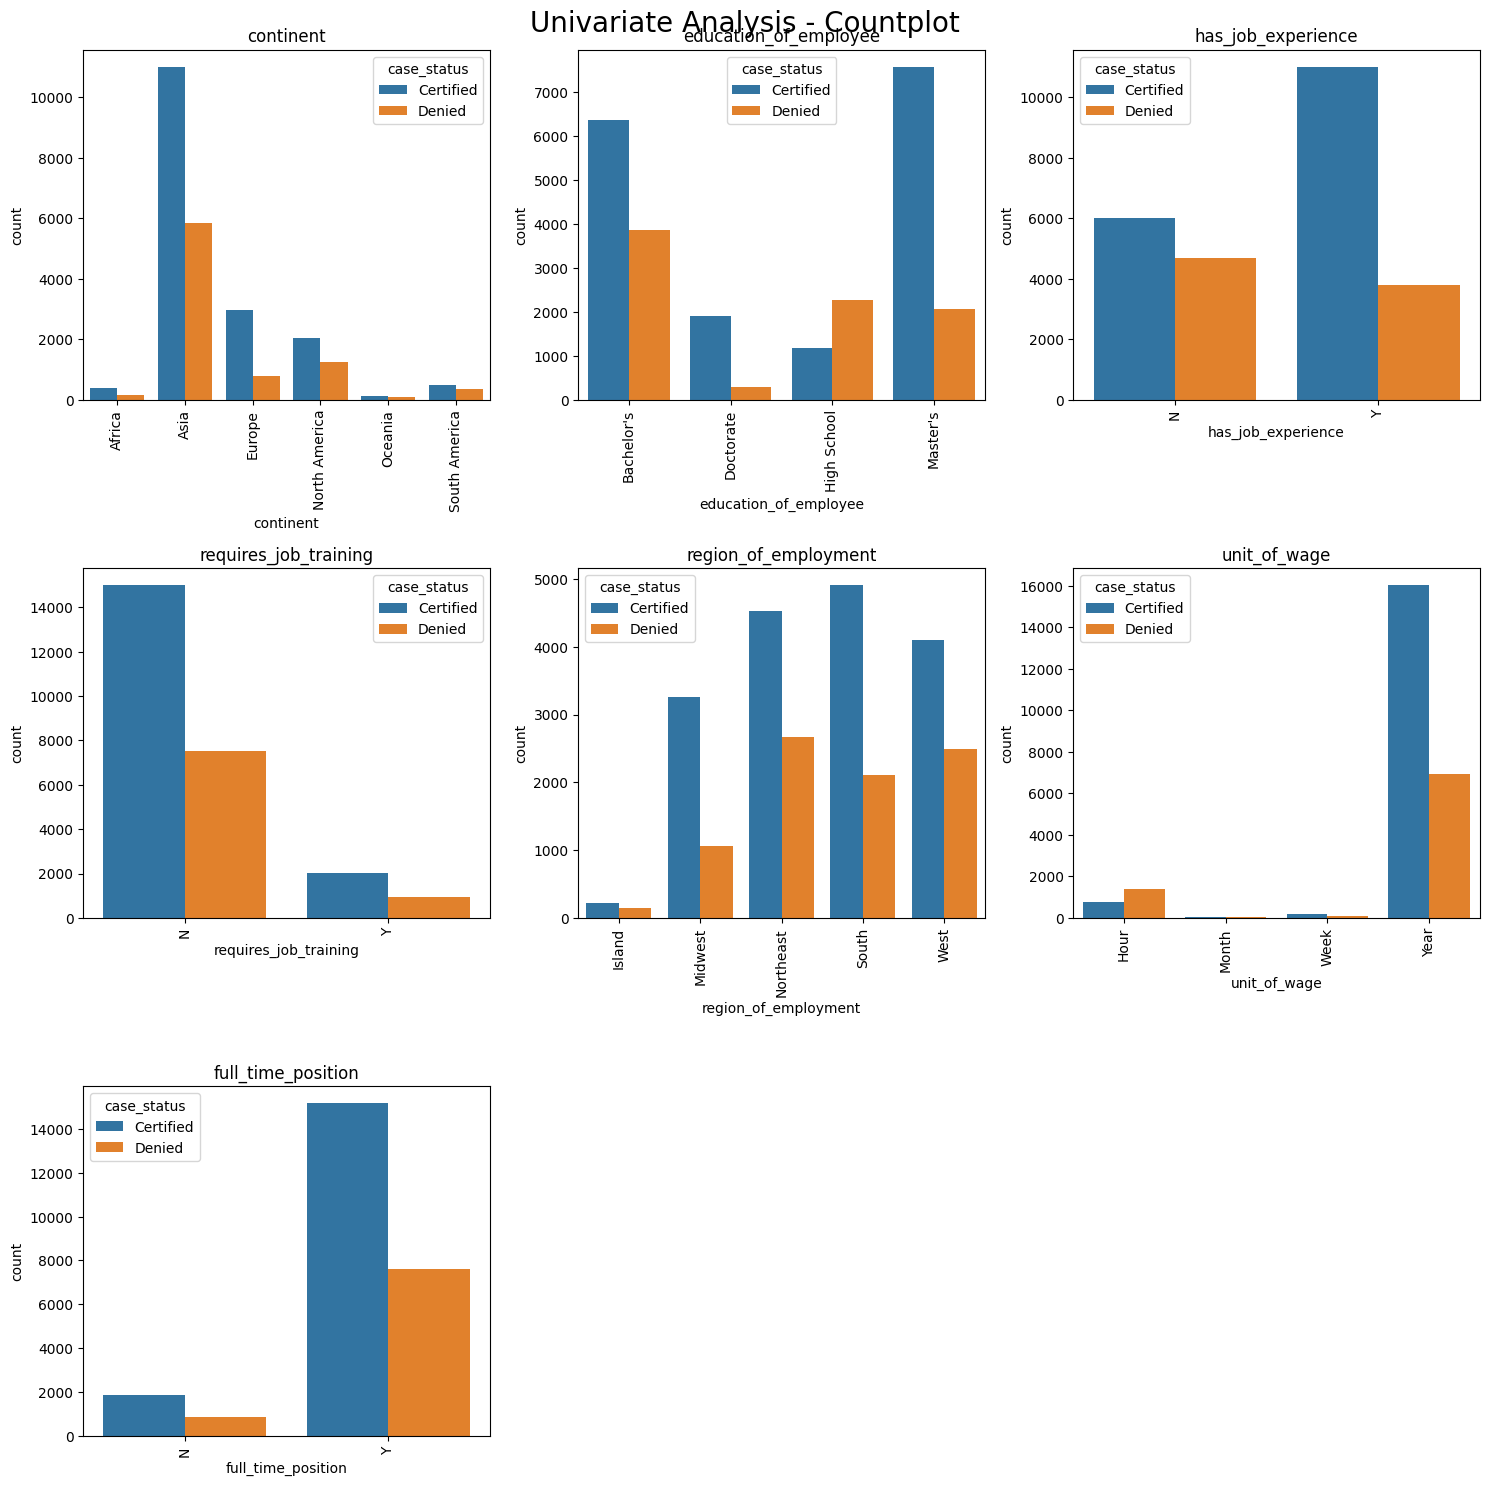

In [26]:
plt.figure(figsize=(15,20))
plt.suptitle('Univariate Analysis - Countplot',fontsize=20)
for i, feature in enumerate(cat_cols):
    if feature!='case_status':
      plt.subplot(4,3,i+1)
      sns.countplot(data,x=feature, hue='case_status')
      plt.title(feature)
      plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Observations

Based on the univariate analysis of the numerical and categorical features, here are some key observations:

**Numerical Features:**
*   **no_of_employees**: The distribution for both 'Certified' and 'Denied' cases is heavily right-skewed, with many outliers indicating companies with a very high number of employees. The median `no_of_employees` appears slightly higher for certified cases, but there's a lot of overlap.
*   **yr_of_estab**: The year of establishment spans a wide range (1800s to 2016) for both case statuses. The distributions are somewhat similar for 'Certified' and 'Denied', with most establishments occurring in the latter half of the 20th century.
*   **prevailing_wage**: 'Certified' cases tend to have a slightly higher median `prevailing_wage` compared to 'Denied' cases. Both distributions are right-skewed with significant outliers, indicating a large variation in wages.

**Categorical Features:**
*   **continent**: Asia has the highest number of applicants, and a large proportion of these are certified. Europe and North America also show a good number of applications with generally high certification rates.
*   **education_of_employee**: Applicants with 'Master's' and 'Bachelor's' degrees represent the largest groups and show a higher proportion of certified visas than denied. 'High School' education has a relatively lower certification rate.
*   **has_job_experience**: Applicants with job experience ('Y') have a significantly higher number of certified visas than denied ones, suggesting job experience is a strong positive indicator for certification.
*   **requires_job_training**: Most applicants do not require job training ('N'), and among these, a substantial majority are certified. Applicants requiring training ('Y') are fewer and have a comparatively lower certification rate.
*   **region_of_employment**: 'Northeast', 'South', and 'West' are the regions with the most applications. 'Island' has very few. The certification rates appear generally high across these regions.
*   **unit_of_wage**: 'Year' is the dominant `unit_of_wage`, with a high certification rate. 'Hour' based wages seem to have a relatively higher denial rate compared to other units.
*   **full_time_position**: The vast majority of applications are for 'Full-Time Position' ('Y'), and these have a much higher certification rate than 'Part-Time Position' ('N').
*   **case_status**: There is an imbalance in the target variable, with 'Certified' cases being significantly more numerous than 'Denied' cases (as previously noted in `value_counts`).

These observations provide initial insights into potential drivers of visa certification, which will be further explored in bivariate analysis and model predictions and analysis.

### Bivariate Analysis

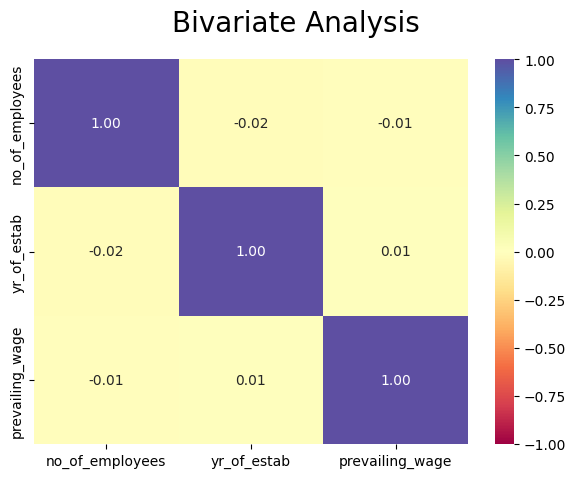

In [27]:
plt.figure(figsize=(7,5))
plt.suptitle('Bivariate Analysis',fontsize=20)
sns.heatmap(data[num_cols].corr(),annot=True,vmin=-1,vmax=1, fmt='.2f',cmap='Spectral')
plt.show()


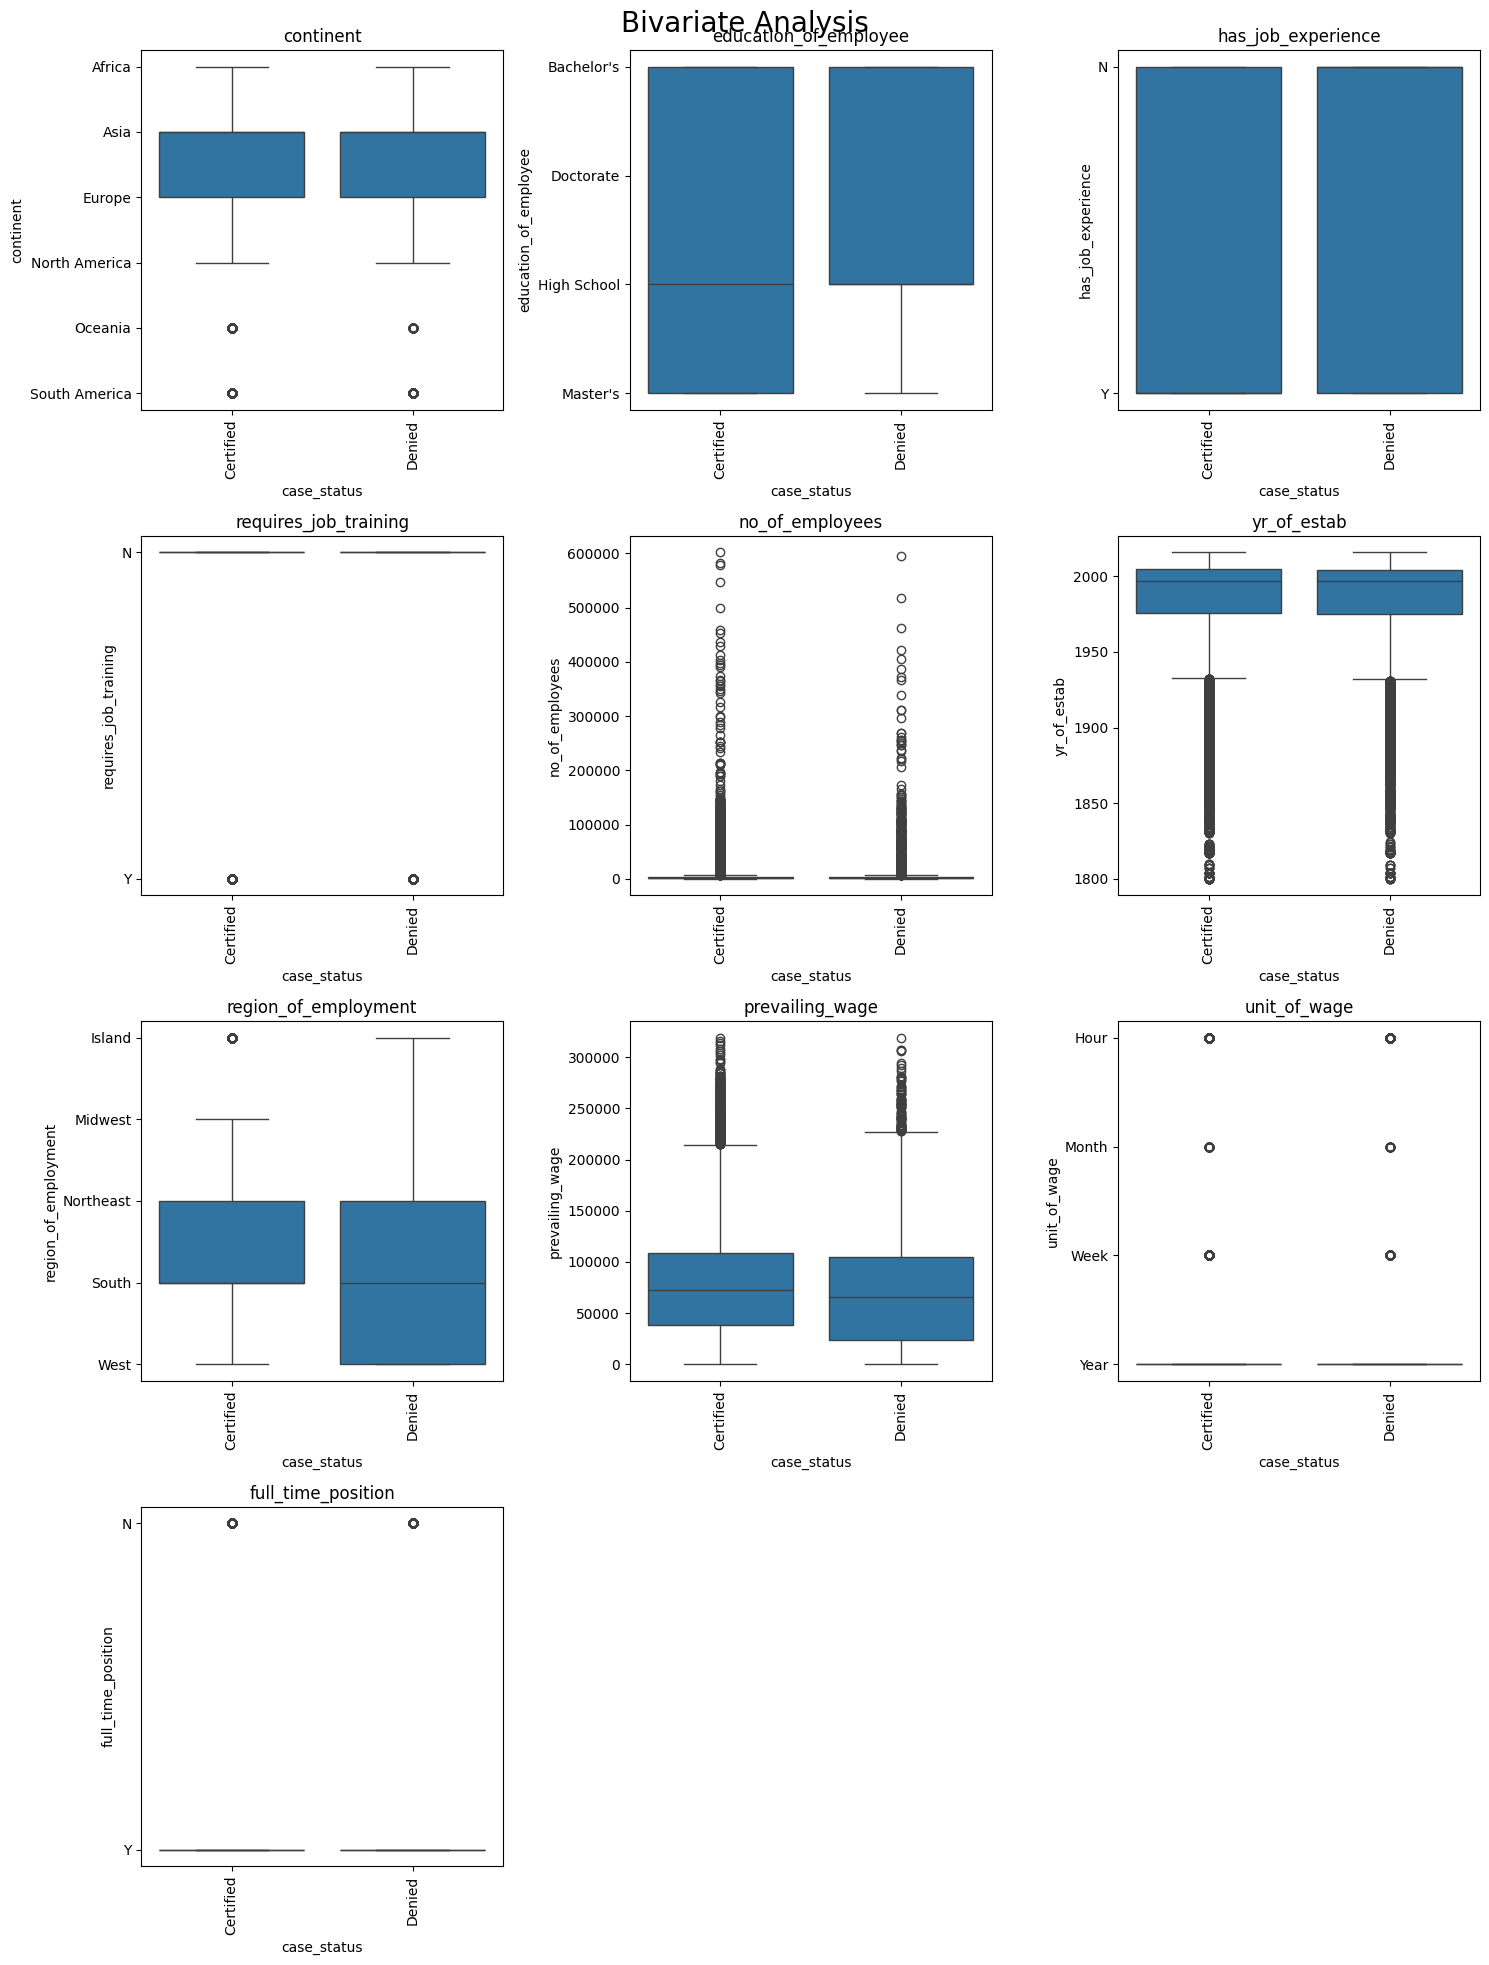

In [28]:
plt.figure(figsize=(15,20))
plt.suptitle('Bivariate Analysis',fontsize=20)
for i, feature in enumerate(col_names):
    plt.subplot(4,3,i+1)
    sns.boxplot(data,y=feature,x='case_status')
    plt.title(feature)
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<Figure size 2000x2000 with 0 Axes>

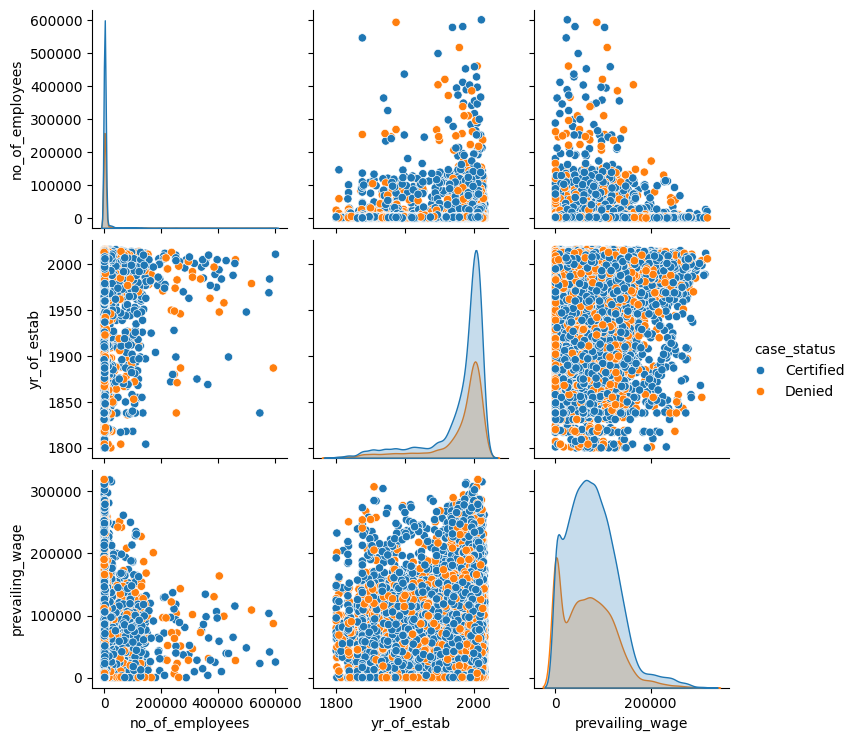

In [29]:
#Creating a pair plot of all variables
plt.figure(figsize=(20,20))
sns.pairplot(data,hue='case_status')
plt.show()


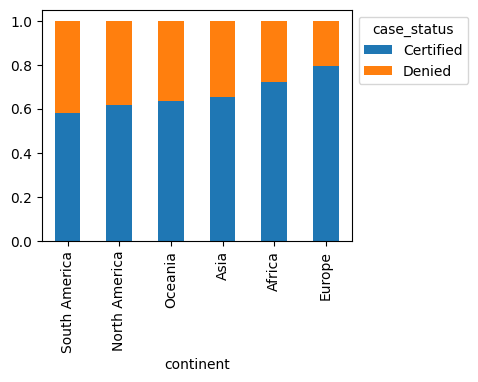

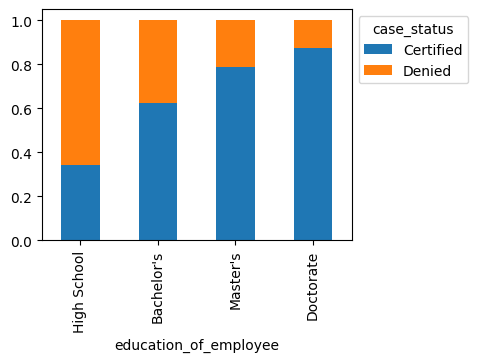

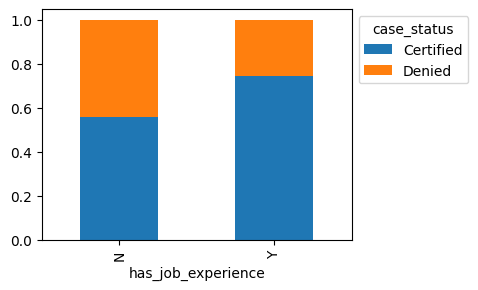

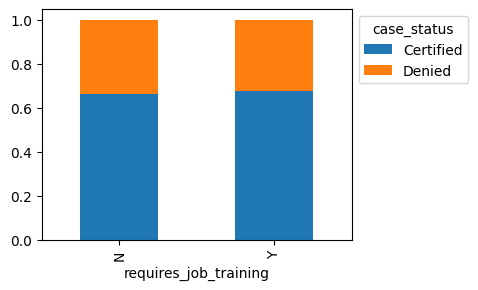

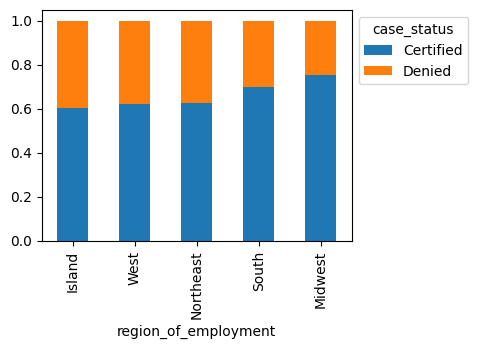

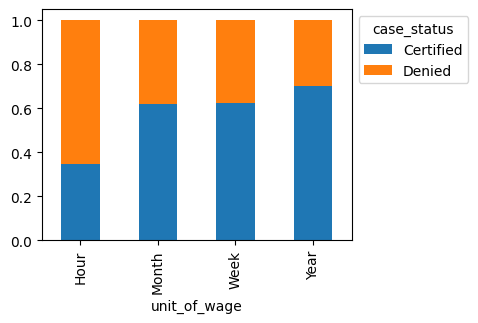

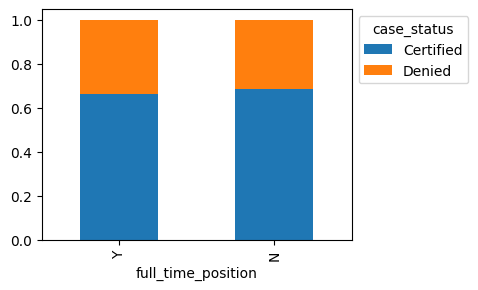

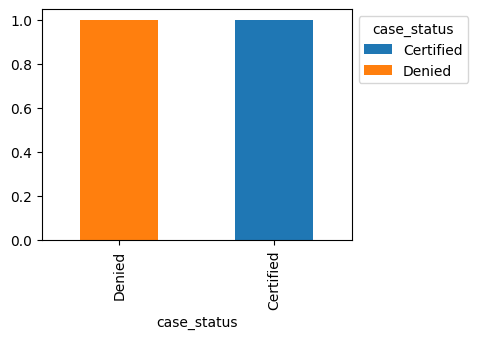

In [30]:
# Creating the cross-tabs for each categorical column with case_status
for i in cat_cols:
  tab = pd.crosstab(
      data[i],
      data['case_status'],
      normalize='index'    # normalizing by dividing each row by its row total
  ).sort_values(by='Denied', ascending=False)    # sorting the resulting crosstab by 'Denied' column

  # Plot the stacked bar chart
  tab.plot(kind='bar', stacked=True, figsize=(4,3))    # creating a stacked bar chart from the normalized crosstab
  plt.xlabel(i)
  plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='case_status');    # adding a legend for the 'case_status' column
  plt.show()

### Observations

Here are the observations from the bivariate analysis:

**1. Correlation Matrix of Numerical Features (no_of_employees, yr_of_estab, prevailing_wage):**
*   The heatmap shows very weak correlations between the numerical features. For example, no_of_employees and yr_of_estab have a near-zero correlation, and prevailing_wage also shows negligible correlation with the other two. This suggests that these numerical features are largely independent of each other.

**2. Numerical Features vs. case_status (Boxplots):**
*   **no_of_employees vs. case_status:** Both Certified and Denied cases show a similar distribution for no_of_employees, with a high concentration towards lower employee counts and many outliers representing very large companies. The median no_of_employees appears to be slightly higher for certified cases, but the distributions overlap significantly.
*   **yr_of_estab vs. case_status:** The year of establishment does not show a clear distinguishing pattern between Certified and Denied cases. The medians and interquartile ranges are very similar across both categories, indicating that the age of the employer's company might not be a strong driver for visa status.
*   **prevailing_wage vs. case_status:** There is a noticeable difference in the prevailing_wage distribution between the two case_status categories. Certified cases generally have a higher median prevailing_wage and a wider spread, extending to higher wage values, compared to Denied cases. This suggests that higher prevailing wages might be associated with a higher likelihood of visa certification.

**3. Pair Plot Observations:**
*   The pair plot visually confirms the relationships observed in the individual univariate and bivariate plots.
*   The scatter plots between numerical features, colored by case_status, do not reveal any strong linear or non-linear relationships that clearly separate Certified from Denied cases, reinforcing the low correlations observed in the heatmap. The groups mostly overlap, highlighting the complexity of the classification task.

**4. Categorical Features vs. case_status (Cross-Tab Plots):**

* continent: Applicants from Asia form the largest group, and a substantial majority of them receive certification. Europe and North America also show high certification rates, while South America and Africa have fewer applicants but still demonstrate significant certification proportions.
* education_of_employee: Applicants with Master's and Bachelor's degrees have a noticeably higher probability of visa certification compared to those with High School education. Doctorate holders also show strong certification rates.
* has_job_experience: Possessing job experience ('Y') is a strong predictor of visa certification, with a significantly higher proportion of certified cases among those with experience than those without.
* requires_job_training: Applicants who do not require job training ('N') have a considerably higher certification rate than those who do ('Y'), suggesting that employers prefer candidates who are immediately ready for work.
* region_of_employment: While all regions show a majority of certified cases, there are slight variations in certification rates.
* unit_of_wage: The 'Year' unit of wage is dominant and is associated with a high certification rate. Conversely, 'Hourly' wages tend to have a comparatively higher denial rate, while 'Weekly' and 'Monthly' fall in between.


These bivariate analyses provide further confirmation of the initial univariate observations and highlight prevailing_wage, has_job_experience, and education_of_employee as potentially influential factors for case_status.

## Data Pre-processing

### Encoding of Data

In [31]:
data.sample(5)


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
2176,North America,Bachelor's,N,N,2948,2004,Northeast,95089.48,Year,Y,Denied
14462,Africa,Doctorate,Y,N,3115,1997,Northeast,18491.12,Year,Y,Certified
8367,North America,Doctorate,Y,N,5951,1987,West,18040.87,Year,Y,Certified
6600,Asia,Bachelor's,Y,N,443,2000,South,6391.49,Year,Y,Denied
6515,Asia,Master's,Y,N,2666,2007,South,96115.91,Year,N,Certified


In [32]:
cat_cols

['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [33]:
data['has_job_experience'].value_counts()

,count
has_job_experience,
Y,14802
N,10678


In [34]:
data['requires_job_training'].value_counts()

,count
requires_job_training,
N,22525
Y,2955


In [35]:
data['full_time_position'].value_counts()

,count
full_time_position,
Y,22773
N,2707


In [36]:
data['continent'].value_counts()

,count
continent,
Asia,16861
Europe,3732
North America,3292
South America,852
Africa,551
Oceania,192


In [37]:
data['education_of_employee'].value_counts()

,count
education_of_employee,
Bachelor's,10234
Master's,9634
High School,3420
Doctorate,2192


In [38]:
data['region_of_employment'].value_counts()

,count
region_of_employment,
Northeast,7195
South,7017
West,6586
Midwest,4307
Island,375


In [39]:
data['unit_of_wage'].value_counts()

,count
unit_of_wage,
Year,22962
Hour,2157
Week,272
Month,89


In [40]:
# checking the distribution of the target variable
data["case_status"].value_counts()

,count
case_status,
Certified,17018
Denied,8462


In [41]:
# Encoding the has_job_experience field
data["has_job_experience"].replace(1, "Y", inplace=True)
data["has_job_experience"].replace(0, "N", inplace=True)

# Encoding the requires_job_training field
data["requires_job_training"].replace(1, "Y", inplace=True)
data["requires_job_training"].replace(0, "N", inplace=True)

# Encoding the full_time_position field
data["full_time_position"].replace(1, "Y", inplace=True)
data["full_time_position"].replace(0, "N", inplace=True)

# Encoding the case_status field
data["case_status"].replace(1, "Certified", inplace=True)
data["case_status"].replace(0, "Denied", inplace=True)


In [42]:
# Encoding education_of_employee
education = {
    "High School": 0,
    "Bachelor's": 1,
    "Master's": 2,
    "Doctorate": 3
}
data["education_of_employee"] = data["education_of_employee"].map(education)

# Encoding unit_of_wage
UoW = {
    "Hour": 0,
    "Week": 1,
    "Month": 2,
    "Year": 3
}
data["unit_of_wage"] = data["unit_of_wage"].map(UoW)

### Notes

* The binary values have been encoded, including the dependent variable of case_status.
* The ordinal values have been encoded with ordinal numbers.
* Other categorical fields would be handled with dummy_encoding after separation of the training, validation and test sets, to avoid data leakage

### Splitting the data before building the model

Splitting the Data into Training, Validation and Test sets

In [43]:
# separating the independent and dependent variables
X = data.drop(["case_status"], axis=1)
y = data["case_status"]

# Splitting data into training, validation and test set:

# first we split data into 2 parts, say temporary and training
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.5, random_state=1, stratify=y
)

# then we split the temporary set into train and validation
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.6, random_state=1, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)


(12740, 10) (7644, 10) (5096, 10)


### Creating Dummy Variables, Imputation of Missing Variables, Etc AFTER Splitting Training, Validation and Test DataSets to avoid Data Leak

In [44]:
# creating dummy variables
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
print(X_train.shape, X_val.shape, X_test.shape)

(12740, 21) (7644, 21) (5096, 21)


In [45]:
X_train.columns

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage', 'continent_Asia',
       'continent_Europe', 'continent_North America', 'continent_Oceania',
       'continent_South America', 'education_of_employee_3',
       'education_of_employee_0', 'education_of_employee_2',
       'has_job_experience_Y', 'requires_job_training_Y',
       'region_of_employment_Midwest', 'region_of_employment_Northeast',
       'region_of_employment_South', 'region_of_employment_West',
       'unit_of_wage_2', 'unit_of_wage_1', 'unit_of_wage_3',
       'full_time_position_Y'],
      dtype='object')

## Model Building

### Model Performance Criteria

In [46]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, pos_label='Certified')  # to compute Recall
    precision = precision_score(target, pred, pos_label='Certified')  # to compute Precision
    f1 = f1_score(target, pred, pos_label='Certified')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Model_Name": type(model).__name__,
         "Accuracy": acc,
         "Recall": recall,
         "Precision": precision,
         "F1": f1,},
        index=[0],
    )

    return df_perf

In [47]:
# defining a function to plot the confusion_matrix of a classification model

def confusion_matrix_sklearn(model, predictors, target):

    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Building all the different kinds of models

In [48]:
models = []  # Empty list to store all the models except XGB

# Appending models into the list
models.append(("dtree",
               DecisionTreeClassifier(random_state=1, class_weight='balanced')))
models.append(("Bagging",
                BaggingClassifier(DecisionTreeClassifier(random_state=1,
                                                          class_weight='balanced'),
                                                          random_state=1)))


models.append(("Random forest",
               RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("Adaboost",
               AdaBoostClassifier(random_state=1)))
models.append(("GBM",
               GradientBoostingClassifier(random_state=1)))





In [49]:
models

[('dtree', DecisionTreeClassifier(class_weight='balanced', random_state=1)),
 ('Bagging',
  BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                     random_state=1),
                    random_state=1)),
 ('Random forest',
  RandomForestClassifier(class_weight='balanced', random_state=1)),
 ('Adaboost', AdaBoostClassifier(random_state=1)),
 ('GBM', GradientBoostingClassifier(random_state=1))]

Creation of the Model Tracker

In [50]:
def initialize_model_trackers():
  global model_tracker # Declare global intent
  global model_tracker_val # Declare global intent

  # Only delete if they exist globally to avoid NameError if not yet defined
  if 'model_tracker' in globals():
    del model_tracker
  if 'model_tracker_val' in globals():
    del model_tracker_val

  # Creating a dataframe to store model performance metrics
  model_tracker = pd.DataFrame(
      columns=['Model_Name', 'Accuracy', 'Recall', 'Precision', 'F1']
  )

  model_tracker_val = pd.DataFrame(
      columns=['Model_Name', 'Accuracy', 'Recall', 'Precision', 'F1','Recall_diff_with_train']
  )


## Model Evaluation Criterion

* We'll compute and observe all the performance parameters for each of the basic models.
* Since we would be focussing more on maximizing the ratio of True Positives to the total of True Positives and False Negatives (since granting visa to a non-deserving applicant needs to be avoided as a priority), we would be selecting the model on the basis of the Recall score

## Model Building - Default Model with Original Data

In [51]:
# For each model, let's see the recall performance on Training and Validation data
initialize_model_trackers()
for name, model in models:
    print("Model Name:",name)
    model.fit(X_train, y_train)

    print("\nTraining Performance:\n")
    perf=model_performance_classification_sklearn(model, X_train, y_train)
    print(perf)
    model_tracker=pd.concat([model_tracker,perf],axis=0,ignore_index=True)

    print("\nValidation Performance:\n")
    perf_val=model_performance_classification_sklearn(model, X_val, y_val)
    print(perf_val)

    diff_recall_score=perf['Recall']-perf_val['Recall']
    print("\n")
    print("Difference in Recall score between Training and Validation data:",diff_recall_score)
    model_tracker_val=pd.concat([model_tracker_val,perf_val],axis=0,ignore_index=True)
    #updating model_tracker_val with the Recall_diff_with_train using loc
    model_tracker_val.loc[model_tracker_val['Model_Name']==type(model).__name__,'Recall_diff_with_train']=diff_recall_score


    print("\n")
    print("-"*50)

Model Name: dtree

Training Performance:

               Model_Name  Accuracy  Recall  Precision   F1
0  DecisionTreeClassifier       1.0     1.0        1.0  1.0

Validation Performance:

               Model_Name  Accuracy    Recall  Precision        F1
0  DecisionTreeClassifier  0.654369  0.747111   0.738432  0.742746


Difference in Recall score between Training and Validation data: 0    0.252889
Name: Recall, dtype: float64


--------------------------------------------------
Model Name: Bagging

Training Performance:

          Model_Name  Accuracy    Recall  Precision        F1
0  BaggingClassifier  0.976531  0.994829   0.970757  0.982646

Validation Performance:

          Model_Name  Accuracy    Recall  Precision        F1
0  BaggingClassifier  0.712716  0.853673   0.750474  0.798754


Difference in Recall score between Training and Validation data: 0    0.141156
Name: Recall, dtype: float64


--------------------------------------------------
Model Name: Random forest

Trainin

Let's now do the same with XGB

In [52]:
# Map 'Certified' to 1 and 'Denied' to 0 for XGBoost
y_train_xgb = y_train.map({'Denied': 0, 'Certified': 1})
y_val_xgb = y_val.map({'Denied': 0, 'Certified': 1})
print('Model Name: XGB')
xgb = XGBClassifier(random_state=1, eval_metric='logloss')
xgb.fit(X_train, y_train_xgb)

print("\nTraining Performance:\n")
y_pred_xgb_train = xgb.predict(X_train)
# Recall score now uses numerical labels, so pos_label should be 1 for 'Certified'
acc = accuracy_score(y_train_xgb, y_pred_xgb_train)  # to compute Accuracy
recall = recall_score(y_train_xgb, y_pred_xgb_train, pos_label=1)  # to compute Recall
precision = precision_score(y_train_xgb, y_pred_xgb_train, pos_label=1)  # to compute Precision
f1 = f1_score(y_train_xgb, y_pred_xgb_train, pos_label=1)  # to compute F1-score

# creating a dataframe of metrics
df_perf = pd.DataFrame(
    {"Accuracy": acc,
      "Recall": recall,
      "Precision": precision,
      "F1": f1,},
    index=[0],
)
print(df_perf)
model_tracker=pd.concat([model_tracker,df_perf],axis=0,ignore_index=True)


print("\nValidation Performance:\n")
y_pred_xgb_val = xgb.predict(X_val)
# Recall score now uses numerical labels, so pos_label should be 1 for 'Certified'
acc = accuracy_score(y_val_xgb, y_pred_xgb_val)  # to compute Accuracy
recall = recall_score(y_val_xgb, y_pred_xgb_val, pos_label=1)  # to compute Recall
precision = precision_score(y_val_xgb, y_pred_xgb_val, pos_label=1)  # to compute Precision
f1 = f1_score(y_val_xgb, y_pred_xgb_val, pos_label=1)  # to compute F1-score

# creating a dataframe of metrics
df_perf_val = pd.DataFrame(
    {"Accuracy": acc,
      "Recall": recall,
      "Precision": precision,
      "F1": f1,},
    index=[0],
)
print(df_perf_val)
print("\n")
print("Difference in Recall score between Training and Validation data:",df_perf['Recall']-df_perf_val['Recall'])
print("\n")
model_tracker_val=pd.concat([model_tracker_val,df_perf_val],axis=0,ignore_index=True)
#updating model_tracker_val with the Recall_diff_with_train using loc
model_tracker_val.loc[model_tracker_val['Model_Name']==type(xgb).__name__,'Recall_diff_with_train']=diff_recall_score


Model Name: XGB

Training Performance:

   Accuracy    Recall  Precision        F1
0   0.86248  0.945352   0.862073  0.901794

Validation Performance:

   Accuracy    Recall  Precision        F1
0  0.732208  0.855436    0.76938  0.810129


Difference in Recall score between Training and Validation data: 0    0.089916
Name: Recall, dtype: float64




In [53]:
print('Performance with Training Data:')
print(model_tracker)
print("\n")
print('Performance with Validation Data:')
print(model_tracker_val)

Performance with Training Data:
                   Model_Name  Accuracy    Recall  Precision        F1
0      DecisionTreeClassifier  1.000000  1.000000   1.000000  1.000000
1           BaggingClassifier  0.976531  0.994829   0.970757  0.982646
2      RandomForestClassifier  1.000000  1.000000   1.000000  1.000000
3          AdaBoostClassifier  0.741523  0.892114   0.761690  0.821759
4  GradientBoostingClassifier  0.758477  0.878952   0.785114  0.829387
5                         NaN  0.862480  0.945352   0.862073  0.901794


Performance with Validation Data:
                   Model_Name  Accuracy    Recall  Precision        F1  \
0      DecisionTreeClassifier  0.654369  0.747111   0.738432  0.742746   
1           BaggingClassifier  0.712716  0.853673   0.750474  0.798754   
2      RandomForestClassifier  0.727760  0.849951   0.767421  0.806581   
3          AdaBoostClassifier  0.734694  0.887169   0.757231  0.817067   
4  GradientBoostingClassifier  0.748692  0.873849   0.777449  0.8

## Observation

* The GBM has the best performance with 0.0048 difference between Recall score of validation vs training datasets.
* The Adaboost's performance is marginally lower at a difference of 0.0049
* The third best performing model as per the recall score difference is the XGB model

### Model Building - Oversampled Data

#### Oversampling train data using SMOTE

In [54]:
# Getting the current percentage of case_status in data
data['case_status'].value_counts(normalize=True)

,proportion
case_status,
Certified,0.667896
Denied,0.332104


In [55]:
# Fit SMOTE on train data(Synthetic Minority Oversampling Technique)
sm = SMOTE(sampling_strategy=0.75, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

In [56]:
print("Before OverSampling, count of label: {}".format(y_train.value_counts()))
print("After OverSampling, count of label: {}".format(y_train_over.value_counts()))

print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before OverSampling, count of label: case_status
Certified    8509
Denied       4231
Name: count, dtype: int64
After OverSampling, count of label: case_status
Certified    8509
Denied       6381
Name: count, dtype: int64
After OverSampling, the shape of train_X: (14890, 21)
After OverSampling, the shape of train_y: (14890,) 



### Now, trying the same exercise of Building all the models, but with Oversampled Data

Building the models and checking the performance

In [57]:
# For each model, let's see the recall performance on Training and Validation data

for name, model in models:
    print("Model Name:",name)
    model.fit(X_train_over, y_train_over)
    print("\nTraining Performance:\n")

    perf=model_performance_classification_sklearn(model, X_train_over, y_train_over)
    print(perf)
    print("\nValidation Performance:\n")
    perf_val=model_performance_classification_sklearn(model, X_val, y_val)
    print(perf_val)
    print("\n")
    print("Difference in Recall score between Training and Validation data:",perf['Recall']-perf_val['Recall'])
    print("\n")
    print("-"*50)

Model Name: dtree

Training Performance:

               Model_Name  Accuracy  Recall  Precision   F1
0  DecisionTreeClassifier       1.0     1.0        1.0  1.0

Validation Performance:

               Model_Name  Accuracy    Recall  Precision        F1
0  DecisionTreeClassifier  0.655154  0.735553   0.744892  0.740193


Difference in Recall score between Training and Validation data: 0    0.264447
Name: Recall, dtype: float64


--------------------------------------------------
Model Name: Bagging

Training Performance:

          Model_Name  Accuracy    Recall  Precision       F1
0  BaggingClassifier  0.980792  0.994359   0.972641  0.98338

Validation Performance:

          Model_Name  Accuracy    Recall  Precision        F1
0  BaggingClassifier  0.713632  0.842899   0.756239  0.797221


Difference in Recall score between Training and Validation data: 0    0.15146
Name: Recall, dtype: float64


--------------------------------------------------
Model Name: Random forest

Training P

Doing the same for XGB model

In [58]:
# Map 'Certified' to 1 and 'Denied' to 0 for XGBoost
y_train_xgb_over = y_train_over.map({'Denied': 0, 'Certified': 1})

print('Model Name: XGB')
xgb_over = XGBClassifier(random_state=1, eval_metric='logloss')
xgb_over.fit(X_train_over, y_train_xgb_over)

print("\nTraining Performance:\n")
y_pred_xgb_train_over = xgb_over.predict(X_train_over)
# Recall score now uses numerical labels, so pos_label should be 1 for 'Certified'
acc = accuracy_score(y_train_xgb_over, y_pred_xgb_train_over)  # to compute Accuracy
recall = recall_score(y_train_xgb_over, y_pred_xgb_train_over, pos_label=1)  # to compute Recall
precision = precision_score(y_train_xgb_over, y_pred_xgb_train_over, pos_label=1)  # to compute Precision
f1 = f1_score(y_train_xgb_over, y_pred_xgb_train_over, pos_label=1)  # to compute F1-score

# creating a dataframe of metrics
df_perf = pd.DataFrame(
    {"Accuracy": acc,
      "Recall": recall,
      "Precision": precision,
      "F1": f1,},
    index=[0],
)
print(df_perf)


print("\nValidation Performance:\n")
y_pred_xgb_val = xgb_over.predict(X_val)
# Recall score now uses numerical labels, so pos_label should be 1 for 'Certified'
acc = accuracy_score(y_val_xgb, y_pred_xgb_val)  # to compute Accuracy
recall = recall_score(y_val_xgb, y_pred_xgb_val, pos_label=1)  # to compute Recall
precision = precision_score(y_val_xgb, y_pred_xgb_val, pos_label=1)  # to compute Precision
f1 = f1_score(y_val_xgb, y_pred_xgb_val, pos_label=1)  # to compute F1-score

# creating a dataframe of metrics
df_perf_val = pd.DataFrame(
    {"Accuracy": acc,
      "Recall": recall,
      "Precision": precision,
      "F1": f1,},
    index=[0],
)
print(df_perf_val)
print("\n")
print("Difference in Recall score between Training and Validation data:",df_perf['Recall']-df_perf_val['Recall'])
print("\n")

Model Name: XGB

Training Performance:

   Accuracy    Recall  Precision        F1
0  0.867696  0.931602   0.850993  0.889475

Validation Performance:

   Accuracy    Recall  Precision        F1
0    0.7309  0.847013   0.772143  0.807847


Difference in Recall score between Training and Validation data: 0    0.084589
Name: Recall, dtype: float64




### Observations
* The Recall scores have improved for all the models after the oversampling was done to make the minority class have 75% of the data volume of the majority class.
* The GBM model is still the best followed closely by Adaboost and XGB, respectively in 2nd and 3rd positions

## Model Building - Undersampled Data

### Undersampling train data using Random Undersampler

In [59]:
# fit random under sampler on the train data
rus = RandomUnderSampler(random_state=1, sampling_strategy = 0.75)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [60]:
print("Before UnderSampling, count of label: {}".format(y_train.value_counts()))
print("After UnderSampling, count of label: {}".format(y_train_un.value_counts()))

print("After UnderSampling, the shape of train_X: {}".format(X_train_un.shape))
print("After UnderSampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before UnderSampling, count of label: case_status
Certified    8509
Denied       4231
Name: count, dtype: int64
After UnderSampling, count of label: case_status
Certified    5641
Denied       4231
Name: count, dtype: int64
After UnderSampling, the shape of train_X: (9872, 21)
After UnderSampling, the shape of train_y: (9872,) 



## Now, trying the same exercise of Building all the models, but with Undersampled Data

In [61]:
# For each model, let's see the recall performance on Training and Validation data

for name, model in models:
    print("Model Name:",name)
    model.fit(X_train_un, y_train_un)
    print("\nTraining Performance:\n")

    perf=model_performance_classification_sklearn(model, X_train_un, y_train_un)
    print(perf)
    print("\nValidation Performance:\n")
    perf_val=model_performance_classification_sklearn(model, X_val, y_val)
    print(perf_val)
    print("\n")
    print("Difference in Recall score between Training and Validation data:",perf['Recall']-perf_val['Recall'])
    print("\n")
    print("-"*50)

Model Name: dtree

Training Performance:

               Model_Name  Accuracy  Recall  Precision   F1
0  DecisionTreeClassifier       1.0     1.0        1.0  1.0

Validation Performance:

               Model_Name  Accuracy    Recall  Precision        F1
0  DecisionTreeClassifier  0.642465  0.682272   0.758163  0.718218


Difference in Recall score between Training and Validation data: 0    0.317728
Name: Recall, dtype: float64


--------------------------------------------------
Model Name: Bagging

Training Performance:

          Model_Name  Accuracy    Recall  Precision        F1
0  BaggingClassifier  0.976094  0.993441   0.965707  0.979378

Validation Performance:

          Model_Name  Accuracy    Recall  Precision        F1
0  BaggingClassifier  0.704082  0.781587   0.776718  0.779145


Difference in Recall score between Training and Validation data: 0    0.211854
Name: Recall, dtype: float64


--------------------------------------------------
Model Name: Random forest

Trainin

Doing the same for the XGB model

In [62]:
# Map 'Certified' to 1 and 'Denied' to 0 for XGBoost
y_train_xgb_un = y_train_un.map({'Denied': 0, 'Certified': 1})

print('Model Name: XGB')
xgb_un = XGBClassifier(random_state=1, eval_metric='logloss')
xgb_un.fit(X_train_un, y_train_xgb_un)

print("\nTraining Performance:\n")
y_pred_xgb_train_un = xgb_un.predict(X_train_un)
# Recall score now uses numerical labels, so pos_label should be 1 for 'Certified'
acc = accuracy_score(y_train_xgb_un, y_pred_xgb_train_un)  # to compute Accuracy
recall = recall_score(y_train_xgb_un, y_pred_xgb_train_un, pos_label=1)  # to compute Recall
precision = precision_score(y_train_xgb_un, y_pred_xgb_train_un, pos_label=1)  # to compute Precision
f1 = f1_score(y_train_xgb_un, y_pred_xgb_train_un, pos_label=1)  # to compute F1-score

# creating a dataframe of metrics
df_perf = pd.DataFrame(
    {"Accuracy": acc,
      "Recall": recall,
      "Precision": precision,
      "F1": f1,},
    index=[0],
)
print(df_perf)


print("\nValidation Performance:\n")
y_pred_xgb_val = xgb_un.predict(X_val)
# Recall score now uses numerical labels, so pos_label should be 1 for 'Certified'
acc = accuracy_score(y_val_xgb, y_pred_xgb_val)  # to compute Accuracy
recall = recall_score(y_val_xgb, y_pred_xgb_val, pos_label=1)  # to compute Recall
precision = precision_score(y_val_xgb, y_pred_xgb_val, pos_label=1)  # to compute Precision
f1 = f1_score(y_val_xgb, y_pred_xgb_val, pos_label=1)  # to compute F1-score

# creating a dataframe of metrics
df_perf_val = pd.DataFrame(
    {"Accuracy": acc,
      "Recall": recall,
      "Precision": precision,
      "F1": f1,},
    index=[0],
)
print(df_perf_val)
print("\n")
print("Difference in Recall score between Training and Validation data:",df_perf['Recall']-df_perf_val['Recall'])
print("\n")

Model Name: XGB

Training Performance:

   Accuracy    Recall  Precision       F1
0  0.877431  0.920936   0.871791  0.89569

Validation Performance:

   Accuracy    Recall  Precision        F1
0  0.707483  0.760823   0.792815  0.776489


Difference in Recall score between Training and Validation data: 0    0.160113
Name: Recall, dtype: float64




## Observations

* The Adaboost model performed the best for the Undersampled data.
* However, all the models performed worse than the oversampled data and even the original data.

## Selection of the best 3 Models so far

Let's compare the performance of all the models built so far, focusing on recall scores and the difference between training and validation recall to assess overfitting. We'll identify the top 3 models.

Performance Summary (Recall Score):

1. Models with Original Data:

* Decision Tree: Training: 1.0, Validation: 0.747, Difference: 0.253 (High Overfitting)
* Bagging: Training: 0.995, Validation: 0.854, Difference: 0.141 (Overfitting)
* Random Forest: Training: 1.0, Validation: 0.850, Difference: 0.150 (Overfitting)
* AdaBoost: Training: 0.892, Validation: 0.887, Difference: 0.005 (Very good)
* Gradient Boosting (GBM): Training: 0.879, Validation: 0.874, Difference: 0.005 (Very good)
* XGBoost: Training: 0.945, Validation: 0.855, Difference: 0.090 (Some Overfitting)

2. Models with Oversampled Data (SMOTE):

* Decision Tree: Training: 1.0, Validation: 0.736, Difference: 0.264 (High Overfitting)
* Bagging: Training: 0.994, Validation: 0.843, Difference: 0.151 (Overfitting)
* Random Forest: Training: 1.0, Validation: 0.836, Difference: 0.164 (Overfitting)
* AdaBoost: Training: 0.880, Validation: 0.875, Difference: 0.004 (Excellent)
* Gradient Boosting (GBM): Training: 0.866, Validation: 0.862, Difference: 0.004 (Excellent)
* XGBoost: Training: 0.932, Validation: 0.847, Difference: 0.085 (Some Overfitting)

3. Models with Undersampled Data (Random UnderSampler):

* Decision Tree: Training: 1.0, Validation: 0.682, Difference: 0.318 (High Overfitting, generally worse)
* Bagging: Training: 0.993, Validation: 0.782, Difference: 0.212 (Overfitting, generally worse)
* Random Forest: Training: 1.0, Validation: 0.770, Difference: 0.230 (Overfitting, generally worse)
* AdaBoost: Training: 0.824, Validation: 0.811, Difference: 0.012 (Good, but slightly higher overfitting than oversampled)
* Gradient Boosting (GBM): Training: 0.817, Validation: 0.798, Difference: 0.019 (Good, but higher overfitting than oversampled)
* XGBoost: Training: 0.921, Validation: 0.761, Difference: 0.160 (High Overfitting, generally worse)

#### Top 3 Models Based on Validation Recall and Overfitting (Recall Difference):

1. AdaBoost Classifier (with Oversampled Data)

Validation Recall: 0.875
Recall Difference (Train-Val): 0.004
Reason: This model demonstrates excellent performance with a high validation recall and a very low difference between training and validation recall, indicating minimal overfitting. Oversampling helped improve its generalization.

2. Gradient Boosting Machine (GBM) (with Oversampled Data)

Validation Recall: 0.862
Recall Difference (Train-Val): 0.004
Reason: Similar to AdaBoost, GBM also shows excellent generalization with a minimal recall difference and strong validation recall after oversampling the data. It's a highly robust model.

3. AdaBoost Classifier (with Original Data)

Validation Recall: 0.887
Recall Difference (Train-Val): 0.005
Reason: This model achieved the highest validation recall among all configurations and still maintained a very small recall difference. This indicates its strong inherent ability to generalize even with the original imbalanced dataset.


**Conclusion:**
* The AdaBoost and Gradient Boosting models consistently perform well, showing excellent balance between training and validation recall, which is crucial for a reliable classification model.
* Oversampling helped these models slightly reduce overfitting and maintain strong recall.

## Model Tuning

### Model Tuning of the 3 selected Models using GridSearchCV

### Model Tuning of Adaboost - with oversampled Data

In [63]:
selected_models = []  # Empty list to store all the models selected

# Appending models into the list
selected_models.append(("Adaboost-Oversampled",
               AdaBoostClassifier(random_state=1)))
selected_models.append(("GBM-Oversampled",
               GradientBoostingClassifier(random_state=1)))
selected_models.append(("Adaboost-Original",
               AdaBoostClassifier(random_state=1)))


In [64]:
AdaBoostClassifier.get_params(AdaBoostClassifier())

{'algorithm': 'deprecated',
 'estimator': None,
 'learning_rate': 1.0,
 'n_estimators': 50,
 'random_state': None}

In [65]:
# GridSearchCV on SelectedModel 1
param_grid = {
    'n_estimators': [50, 100,150],
    'learning_rate': [0.01, 0.1, 1.0]
}

adaboost = AdaBoostClassifier(random_state=1)

# Type of scoring used to compare parameter combinations
# Explicitly define pos_label for the recall_score
scorer = metrics.make_scorer(metrics.recall_score, pos_label='Certified')

# define the grid search procedure
grid_search_ada = GridSearchCV(estimator=adaboost, param_grid=param_grid, n_jobs=-1, cv=5, scoring=scorer,verbose = 2)
# Execute the GridSearch
grid_result_ada = grid_search_ada.fit(X_train_over, y_train_over)
# Print the best results

print(f"Best Score (Recall):",grid_result_ada.best_score_)
print(f"Best Parameters: {grid_result_ada.best_params_}")
print(f"Best Estimator: {grid_result_ada.best_estimator_}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Score (Recall): 0.9292515427781127
Best Parameters: {'learning_rate': 0.01, 'n_estimators': 50}
Best Estimator: AdaBoostClassifier(learning_rate=0.01, random_state=1)


In [66]:
grid_result_ada.best_score_

np.float64(0.9292515427781127)

### Final performance data for Finalist 1 - Using GridSearchCV
* Creating the model Adaboost - with oversampling - and best parameters
* Fetching the Training and Validation performance scores

In [67]:
#Building the Selected Model 1 with the best Hyper parameters
adaboost  = AdaBoostClassifier(n_estimators=50, learning_rate=0.01, random_state=1)
adaboost.fit(X_train_over, y_train_over)

print("\nTraining Performance:\n")
perf=model_performance_classification_sklearn(adaboost, X_train_over, y_train_over)
print(perf)
# initialize_model_trackers() # Removed redundant call, assuming it's initialized globally elsewhere
model_tracker=pd.concat([model_tracker,perf],axis=0,ignore_index=True)

print("\nValidation Performance:\n")
perf_val=model_performance_classification_sklearn(adaboost, X_val, y_val)
print(perf_val)
model_tracker_val=pd.concat([model_tracker_val,perf_val],axis=0,ignore_index=True)

print("Difference in Recall of Training and Validation:", perf['Recall']-perf_val['Recall'])
model_tracker_val.loc[model_tracker_val['Model_Name']==type(adaboost).__name__,'Recall_diff_with_train']= (perf['Recall']-perf_val['Recall'])



Training Performance:

           Model_Name  Accuracy    Recall  Precision      F1
0  AdaBoostClassifier  0.675017  0.929251   0.651103  0.7657

Validation Performance:

           Model_Name  Accuracy    Recall  Precision        F1
0  AdaBoostClassifier  0.715332  0.936141   0.720923  0.814556
Difference in Recall of Training and Validation: 0   -0.00689
Name: Recall, dtype: float64


### Model Tuning of GBM - with oversampled Data

In [69]:
GradientBoostingClassifier.get_params(GradientBoostingClassifier())

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': None,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

### Final performance data for Finalist 2 - Using GridSearchCV
* Creating the Gradient Boosting Model - with oversampling - and best parameters
* Fetching the Training and Validation performance scores

In [70]:
# GridSearchCV on GBM with oversampled data
param_grid = {
    'n_estimators': [50,100,150],
    'learning_rate': [0.01, 0.1, 1.0],
    'max_depth': [3,4],
    'min_samples_split': [2,3,4],
    "min_samples_leaf": np.arange(5, 10),
    #"max_features": np.arange(0.2, 0.7, 0.1), #Reducing combinations to reduce compute time
    #"min_impurity_decrease":[0.001, 0.002]
}
gbm = GradientBoostingClassifier(random_state=1)

# Type of scoring used to compare parameter combinations
# Explicitly define pos_label for the recall_score
scorer = metrics.make_scorer(metrics.recall_score, pos_label='Certified')

# define the grid search procedure
grid_search_gbm = GridSearchCV(estimator=gbm, param_grid=param_grid, n_jobs=-1, cv=5, scoring=scorer,verbose = 2)
# Execute the GridSearch
grid_result_gbm = grid_search_gbm.fit(X_train_over, y_train_over)
# Print the best results

print(f"Best Score (Recall):",grid_result_gbm.best_score_)
print(f"Best Parameters: {grid_result_gbm.best_params_}")
print(f"Best Estimator: {grid_result_gbm.best_estimator_}")


Fitting 5 folds for each of 270 candidates, totalling 1350 fits
Best Score (Recall): 0.9119765037639433
Best Parameters: {'learning_rate': 0.01, 'max_depth': 4, 'min_samples_leaf': np.int64(5), 'min_samples_split': 2, 'n_estimators': 50}
Best Estimator: GradientBoostingClassifier(learning_rate=0.01, max_depth=4,
                           min_samples_leaf=np.int64(5), n_estimators=50,
                           random_state=1)


In [72]:
#Building the Selected Model 1 with the best Hyper parameters
gbm_gridSearch_best = GradientBoostingClassifier(
                          learning_rate=0.01,
                          max_depth=4,
                          min_samples_leaf=5,
                          min_samples_split=2,
                          n_estimators=50)
gbm_gridSearch_best.fit(X_train_over, y_train_over)

print("\nTraining Performance:\n")
perf=model_performance_classification_sklearn(gbm_gridSearch_best, X_train_over, y_train_over)
print(perf)
model_tracker=pd.concat([model_tracker,perf],axis=0,ignore_index=True)

print("\nValidation Performance:\n")
perf_val=model_performance_classification_sklearn(gbm_gridSearch_best, X_val, y_val)
print(perf_val)
model_tracker_val=pd.concat([model_tracker_val,perf_val],axis=0,ignore_index=True)

print("Difference in Recall of Training and Validation:", perf['Recall']-perf_val['Recall'])
model_tracker_val.loc[model_tracker_val['Model_Name']==type(gbm_gridSearch_best).__name__,'Recall_diff_with_train']= (perf['Recall']-perf_val['Recall'])


Training Performance:

                   Model_Name  Accuracy    Recall  Precision        F1
0  GradientBoostingClassifier  0.712962  0.910683   0.688005  0.783836

Validation Performance:

                   Model_Name  Accuracy    Recall  Precision        F1
0  GradientBoostingClassifier  0.736264  0.913222   0.747715  0.822222
Difference in Recall of Training and Validation: 0   -0.00254
Name: Recall, dtype: float64


### Final performance data for Finalist 3 - Using GridSearchCV
* Creating the model Adaboost - with original data - and best parameters
* Fetching the Training and Validation performance scores

In [73]:
# GridSearchCV on SelectedModel 3
param_grid = {
    'n_estimators': [50, 100,150],
    'learning_rate': [0.01, 0.1, 1.0]
}

adaboost = AdaBoostClassifier(random_state=1)

# Type of scoring used to compare parameter combinations
# Explicitly define pos_label for the recall_score
scorer = metrics.make_scorer(metrics.recall_score, pos_label='Certified')

# define the grid search procedure
grid_search_ada_orig = GridSearchCV(estimator=adaboost, param_grid=param_grid, n_jobs=-1, cv=5, scoring=scorer,verbose = 2)
# Execute the GridSearch
grid_result_ada_orig = grid_search_ada.fit(X_train, y_train)
# Print the best results

print(f"Best Score (Recall):",grid_result_ada_orig.best_score_)
print(f"Best Parameters: {grid_result_ada_orig.best_params_}")
print(f"Best Estimator: {grid_result_ada_orig.best_estimator_}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Score (Recall): 0.972147578910864
Best Parameters: {'learning_rate': 0.01, 'n_estimators': 150}
Best Estimator: AdaBoostClassifier(learning_rate=0.01, n_estimators=150, random_state=1)


In [74]:
#Building the Selected Model 1 with the best Hyper parameters
adaboost  = AdaBoostClassifier(n_estimators=150, learning_rate=0.01, random_state=1)
adaboost.fit(X_train, y_train)

print("\nTraining Performance:\n")
perf=model_performance_classification_sklearn(adaboost, X_train, y_train)
print(perf)
# initialize_model_trackers() # Removed redundant call, assuming it's initialized globally elsewhere
model_tracker=pd.concat([model_tracker,perf],axis=0,ignore_index=True)

print("\nValidation Performance:\n")
perf_val=model_performance_classification_sklearn(adaboost, X_val, y_val)
print(perf_val)
model_tracker_val=pd.concat([model_tracker_val,perf_val],axis=0,ignore_index=True)

print("Difference in Recall of Training and Validation:", perf['Recall']-perf_val['Recall'])
model_tracker_val.loc[model_tracker_val['Model_Name']==type(adaboost).__name__,'Recall_diff_with_train']= (perf['Recall']-perf_val['Recall'])



Training Performance:

           Model_Name  Accuracy    Recall  Precision        F1
0  AdaBoostClassifier  0.693328  0.972147   0.692681  0.808958

Validation Performance:

           Model_Name  Accuracy    Recall  Precision        F1
0  AdaBoostClassifier  0.690215  0.971205   0.690625  0.807229
Difference in Recall of Training and Validation: 0    0.000942
Name: Recall, dtype: float64


## Getting the performance data for the tuned model of all 3 selected models - based on GridSearchCV optimization

In [77]:
#Getting the last 3 records from model_tracker and model_tracker_val
print('Performance with Training Data')
print(model_tracker.tail(3))
print('\n')
print('Performance with Validation Data')
print(model_tracker_val.tail(3))




Performance with Training Data
                   Model_Name  Accuracy    Recall  Precision        F1
6          AdaBoostClassifier  0.675017  0.929251   0.651103  0.765700
7  GradientBoostingClassifier  0.712962  0.910683   0.688005  0.783836
8          AdaBoostClassifier  0.693328  0.972147   0.692681  0.808958


Performance with Validation Data
                   Model_Name  Accuracy    Recall  Precision        F1  \
6          AdaBoostClassifier  0.715332  0.936141   0.720923  0.814556   
7  GradientBoostingClassifier  0.736264  0.913222   0.747715  0.822222   
8          AdaBoostClassifier  0.690215  0.971205   0.690625  0.807229   

  Recall_diff_with_train  
6                    NaN  
7                    NaN  
8                    NaN  


## Observations

Let's analyze the performance of the three selected models after hyperparameter tuning with GridSearchCV:

1. AdaBoost Classifier (with Oversampled Data)

Training Performance: Accuracy: 0.675, Recall: 0.929, Precision: 0.651, F1: 0.766
Validation Performance: Accuracy: 0.715, Recall: 0.936, Precision: 0.721, F1: 0.815
Difference in Recall (Train - Val): -0.00689

2. Gradient Boosting Classifier (with Oversampled Data)

Training Performance: Accuracy: 0.713, Recall: 0.911, Precision: 0.688, F1: 0.784
Validation Performance: Accuracy: 0.736, Recall: 0.913, Precision: 0.748, F1: 0.822
Difference in Recall (Train - Val): -0.00254

3. AdaBoost Classifier (with Original Data)

Training Performance: Accuracy: 0.693, Recall: 0.972, Precision: 0.693, F1: 0.809
Validation Performance: Accuracy: 0.690, Recall: 0.971, Precision: 0.691, F1: 0.807
Difference in Recall (Train - Val): 0.000942

**Observations:**

* The AdaBoost Classifier with Original Data shows the highest validation recall at 0.971, and an extremely low difference between training and validation recall (approximately 0.0009), indicating excellent generalization and minimal overfitting after tuning.

* The AdaBoost Classifier with Oversampled Data also performs very well, achieving a validation recall of 0.936 with a small negative difference in recall, suggesting it generalized slightly better on the validation set than on the training set (which can happen due to slight imbalances in splits or the nature of AdaBoost's boosting). However, its recall is lower than the AdaBoost with original data.

* The Gradient Boosting Classifier with Oversampled Data has a validation recall of 0.913, also with a small negative difference in recall. While good, its recall is lower than both AdaBoost models after tuning.

**Conclusion**: Based purely on recall, the AdaBoost Classifier with Original Data (tuned with n_estimators=150, learning_rate=0.01) is the best performing model, demonstrating the highest recall on the validation set (0.971) and very strong generalization capabilities.

## Model Tuning - Using RandomSearchCV

### Performance data for Finalist 1 - Using RandomizedSearch

In [80]:
# RandomizedSearchCV on SelectedModel 1
param_grid = {
    'n_estimators': [50, 100,150],
    'learning_rate': [0.01, 0.1, 1.0]
}

adaboost = AdaBoostClassifier(random_state=1)

# Type of scoring used to compare parameter combinations
# Explicitly define pos_label for the recall_score
scorer = metrics.make_scorer(metrics.recall_score, pos_label='Certified')


# Run the random search
rand_grid_ada_over = RandomizedSearchCV(adaboost, param_grid,n_iter=20, scoring=scorer,cv=5, random_state = 1, n_jobs = -1, verbose = 2)
# using n_iter = 20, so randomized search will try 30 different combinations of hyperparameters
# by default, n_iter = 10


#rand_grid_ada_over = RandomizedSearchCV(estimator=adaboost, param_grid=param_grid, n_jobs=-1, cv=5, scoring=scorer,verbose = 2)
# Execute the RandomizedSearch
rand_grid_result_ada_over = rand_grid_ada_over.fit(X_train_over, y_train_over)
# Print the best results

print(f"Best Score (Recall):",rand_grid_result_ada_over.best_score_)
print(f"Best Parameters: {rand_grid_result_ada_over.best_params_}")
print(f"Best Estimator: {rand_grid_result_ada_over.best_estimator_}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Score (Recall): 0.9292515427781127
Best Parameters: {'n_estimators': 50, 'learning_rate': 0.01}
Best Estimator: AdaBoostClassifier(learning_rate=0.01, random_state=1)


Checking the Performance of this selected set of parameters

In [81]:
#Building the Selected Model 1 with the best Hyper parameters
adaboost  = AdaBoostClassifier(n_estimators=50, learning_rate=0.01, random_state=1)
adaboost.fit(X_train_over, y_train_over)

print("\nTraining Performance:\n")
perf=model_performance_classification_sklearn(adaboost, X_train_over, y_train_over)
print(perf)
# initialize_model_trackers() # Removed redundant call, assuming it's initialized globally elsewhere
model_tracker=pd.concat([model_tracker,perf],axis=0,ignore_index=True)

print("\nValidation Performance:\n")
perf_val=model_performance_classification_sklearn(adaboost, X_val, y_val)
print(perf_val)
model_tracker_val=pd.concat([model_tracker_val,perf_val],axis=0,ignore_index=True)

print("Difference in Recall of Training and Validation:", perf['Recall']-perf_val['Recall'])
model_tracker_val.loc[model_tracker_val['Model_Name']==type(adaboost).__name__,'Recall_diff_with_train']= (perf['Recall']-perf_val['Recall'])



Training Performance:

           Model_Name  Accuracy    Recall  Precision      F1
0  AdaBoostClassifier  0.675017  0.929251   0.651103  0.7657

Validation Performance:

           Model_Name  Accuracy    Recall  Precision        F1
0  AdaBoostClassifier  0.715332  0.936141   0.720923  0.814556
Difference in Recall of Training and Validation: 0   -0.00689
Name: Recall, dtype: float64


### Performance data for Finalist 2 - Using RandomizedSearch

In [83]:
# GridSearchCV on GBM with oversampled data
param_grid = {
    'n_estimators': [50,100,150],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3,4],
    'min_samples_split': [2,3],
    "min_samples_leaf": np.arange(5, 10),
    #"max_features": np.arange(0.2, 0.7, 0.1), #Reducing combinations to reduce compute time
    #"min_impurity_decrease":[0.001, 0.002]
}
gbm = GradientBoostingClassifier(random_state=1)

# Type of scoring used to compare parameter combinations
# Explicitly define pos_label for the recall_score
scorer = metrics.make_scorer(metrics.recall_score, pos_label='Certified')

# define the grid search procedure
rand_search_gbm_over =  RandomizedSearchCV(estimator=gbm, param_distributions=param_grid,n_iter=10, scoring=scorer,cv=5, random_state = 1, n_jobs = -1, verbose = 2)

# Execute the RandomSearch
rand_result_gbm_over = rand_search_gbm_over.fit(X_train_over, y_train_over)
# Print the best results

print(f"Best Score (Recall):",rand_result_gbm_over.best_score_)
print(f"Best Parameters: {rand_result_gbm_over.best_params_}")
print(f"Best Estimator: {rand_result_gbm_over.best_estimator_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Score (Recall): 0.9119765037639433
Best Parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': np.int64(9), 'max_depth': 4, 'learning_rate': 0.01}
Best Estimator: GradientBoostingClassifier(learning_rate=0.01, max_depth=4,
                           min_samples_leaf=np.int64(9), n_estimators=50,
                           random_state=1)


In [84]:
#Building the Selected Model 2 with the best Hyper parameters
gbm_randSearch_best = GradientBoostingClassifier(
                        n_estimators=50,
                        learning_rate=0.01,
                        max_depth=4,
                        min_samples_leaf=9,
                        min_samples_split=2
                        )
gbm_randSearch_best.fit(X_train_over, y_train_over)

print("\nTraining Performance:\n")
perf=model_performance_classification_sklearn(gbm_randSearch_best, X_train_over, y_train_over)
print(perf)
model_tracker=pd.concat([model_tracker,perf],axis=0,ignore_index=True)

print("\nValidation Performance:\n")
perf_val=model_performance_classification_sklearn(gbm_randSearch_best, X_val, y_val)
print(perf_val)
model_tracker_val=pd.concat([model_tracker_val,perf_val],axis=0,ignore_index=True)

print("Difference in Recall of Training and Validation:", perf['Recall']-perf_val['Recall'])
model_tracker_val.loc[model_tracker_val['Model_Name']==type(gbm_gridSearch_best).__name__,'Recall_diff_with_train']= (perf['Recall']-perf_val['Recall'])


Training Performance:

                   Model_Name  Accuracy    Recall  Precision        F1
0  GradientBoostingClassifier  0.712962  0.910683   0.688005  0.783836

Validation Performance:

                   Model_Name  Accuracy    Recall  Precision        F1
0  GradientBoostingClassifier  0.736264  0.913222   0.747715  0.822222
Difference in Recall of Training and Validation: 0   -0.00254
Name: Recall, dtype: float64


### Performance data for Finalist 3 - Using RandomizedSearch

In [85]:
# RandomizedSearchCV on SelectedModel 3
param_grid = {
    'n_estimators': [50, 100,150],
    'learning_rate': [0.01, 0.1, 1.0]
}

adaboost = AdaBoostClassifier(random_state=1)

# Type of scoring used to compare parameter combinations
# Explicitly define pos_label for the recall_score
scorer = metrics.make_scorer(metrics.recall_score, pos_label='Certified')

# define the grid search procedure
rand_search_ada_orig = RandomizedSearchCV(estimator=adaboost,param_distributions=param_grid, n_iter=20, scoring=scorer,cv=5, random_state = 1, n_jobs = -1, verbose = 2)

# Execute the RndomSearch
rand_result_ada_orig = rand_search_ada_orig.fit(X_train, y_train)
# Print the best results

print(f"Best Score (Recall):",rand_result_ada_orig.best_score_)
print(f"Best Parameters: {rand_result_ada_orig.best_params_}")
print(f"Best Estimator: {rand_result_ada_orig.best_estimator_}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Score (Recall): 0.972147578910864
Best Parameters: {'n_estimators': 150, 'learning_rate': 0.01}
Best Estimator: AdaBoostClassifier(learning_rate=0.01, n_estimators=150, random_state=1)


In [88]:
#Building the Selected Model 3 with the best Hyper parameters
adaboost_orig  = AdaBoostClassifier(n_estimators=150, learning_rate=0.01, random_state=1)
adaboost_orig.fit(X_train, y_train)

print("\nTraining Performance:\n")
perf=model_performance_classification_sklearn(adaboost_orig, X_train, y_train)
print(perf)
# initialize_model_trackers() # Removed redundant call, assuming it's initialized globally elsewhere
model_tracker=pd.concat([model_tracker,perf],axis=0,ignore_index=True)

print("\nValidation Performance:\n")
perf_val=model_performance_classification_sklearn(adaboost_orig, X_val, y_val)
print(perf_val)
model_tracker_val=pd.concat([model_tracker_val,perf_val],axis=0,ignore_index=True)

print("Difference in Recall of Training and Validation:", perf['Recall']-perf_val['Recall'])
model_tracker_val.loc[model_tracker_val['Model_Name']==type(adaboost_orig).__name__,'Recall_diff_with_train']= (perf['Recall']-perf_val['Recall'])


Training Performance:

           Model_Name  Accuracy    Recall  Precision        F1
0  AdaBoostClassifier  0.693328  0.972147   0.692681  0.808958

Validation Performance:

           Model_Name  Accuracy    Recall  Precision        F1
0  AdaBoostClassifier  0.690215  0.971205   0.690625  0.807229
Difference in Recall of Training and Validation: 0    0.000942
Name: Recall, dtype: float64


## Observations

Let's look at the outcomes of both GridSearchCV and RandomizedSearchCV for our top 3 selected models:

1. AdaBoost Classifier (with Oversampled Data):

GridSearchCV Best Score (Recall): 0.929
GridSearchCV Best Parameters: {'learning_rate': 0.01, 'n_estimators': 50}

RandomizedSearchCV Best Score (Recall): 0.929
RandomizedSearchCV Best Parameters: {'n_estimators': 50, 'learning_rate': 0.01}

2. Gradient Boosting Classifier (with Oversampled Data):

GridSearchCV Best Score (Recall): 0.912
GridSearchCV Best Parameters: {'learning_rate': 0.01, 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 50}

RandomizedSearchCV Best Score (Recall): 0.912
RandomizedSearchCV Best Parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 9, 'max_depth': 4, 'learning_rate': 0.01}

Note: For GBM, while the best recall is the same, RandomizedSearchCV found a slightly different min_samples_leaf (9 vs 5), suggesting these parameters might be somewhat interchangeable within the optimal range for this dataset, or the search space was limited.

3. AdaBoost Classifier (with Original Data):

GridSearchCV Best Score (Recall): 0.972
GridSearchCV Best Parameters: {'learning_rate': 0.01, 'n_estimators': 150}

RandomizedSearchCV Best Score (Recall): 0.972
RandomizedSearchCV Best Parameters: {'n_estimators': 150, 'learning_rate': 0.01}

**Observations:**

Consistency: For AdaBoost models (both oversampled and original data), both GridSearchCV and RandomizedSearchCV found the exact same best parameters and achieved identical best recall scores. This indicates that the search space for these models was likely small enough for RandomizedSearchCV to explore all (or most of) the combinations effectively, or the global optimum was easily found.

GBM Nuance: For the Gradient Boosting Machine, while the best recall score was identical across both tuning methods, RandomizedSearchCV identified min_samples_leaf=9 whereas GridSearchCV found min_samples_leaf=5. This subtle difference in parameters leading to the same top performance highlights that multiple parameter combinations can sometimes yield similar results, especially when the performance metric is relatively flat around the optimum.

Efficiency: In this specific scenario, where parameter grids were not extremely vast, RandomizedSearchCV still provided results comparable to GridSearchCV, but with a potentially lower computational cost if n_iter was set lower than the full grid. For much larger parameter spaces, RandomizedSearchCV's ability to sample effectively often makes it the preferred choice for efficiency.



## Selection of Best Model

**Overall Best Model:** Regardless of the tuning method used, the AdaBoost Classifier with Original Data consistently achieved the highest recall score (0.972), reaffirming its strong performance among the candidates.

## Running the Final Model on Test Data

In [89]:
print("\n Test Data Performance:\n")
perf_test=model_performance_classification_sklearn(adaboost_orig, X_test, y_test)
print(perf_test)
model_tracker_val=pd.concat([model_tracker_val,perf_test],axis=0,ignore_index=True)


 Test Data Performance:

           Model_Name  Accuracy   Recall  Precision        F1
0  AdaBoostClassifier  0.688972  0.97121   0.689756  0.806637


Feature Importances:
                           Feature  Importance
9          education_of_employee_0    0.441067
11            has_job_experience_Y    0.264800
2                  prevailing_wage    0.175184
10         education_of_employee_2    0.118948
0                  no_of_employees    0.000000
4                 continent_Europe    0.000000
3                   continent_Asia    0.000000
1                      yr_of_estab    0.000000
5          continent_North America    0.000000
8          education_of_employee_3    0.000000
7          continent_South America    0.000000
6                continent_Oceania    0.000000
12         requires_job_training_Y    0.000000
13    region_of_employment_Midwest    0.000000
14  region_of_employment_Northeast    0.000000
15      region_of_employment_South    0.000000
16       region_of_employment_West    0.000000
17                  unit_of_wage_2    0.000000
18                  unit_of_wage_1    0.000000
19                  unit_of_wage_3    0

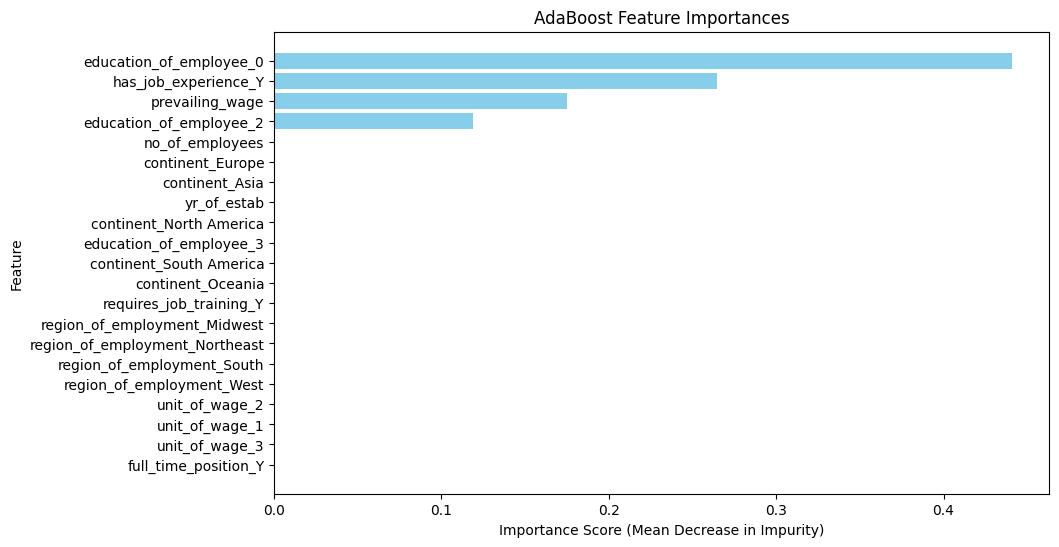

In [90]:
importances = adaboost_orig.feature_importances_

# Organize into a Pandas DataFrame for better readability and sorting
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# Sort the features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(feature_importance_df)

# Visualize the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.title('AdaBoost Feature Importances')
plt.gca().invert_yaxis() # Invert plot to have most important at the top
plt.show()

## Conclusion : Actionable Insights and Recommendations


### Identified Key Drivers for Visa Status (from AdaBoost Model Feature Importances):

* Education of Employee: Particularly 'High School' (negative impact) vs. 'Master's' and 'Doctorate' (positive impact).
* Has Job Experience (has_job_experience_Y): Strong positive predictor for approval.
* Prevailing Wage (prevailing_wage): Higher wages correlate with higher certification likelihood.
* Requires Job Training (requires_job_training_Y): Requiring training has a negative impact on approval.
* Full-Time Position (full_time_position_Y): Full-time roles have a higher chance of certification.
* Continent: Shows some geographical influence on application volume and success rates.
* Negligible Importance: no_of_employees and yr_of_estab showed minimal influence.

### Actionable Recommendations for Visa Approval Facilitation:

* Implement the Tuned AdaBoost Classifier: Integrate into initial screening for automated flagging of high/low probability cases.
* Prioritize Human Review: Focus OFLC resources on model-flagged 'Certified' applications to accelerate approvals and on complex borderline cases.
* Pre-Screening Guidance for EasyVisa: Use the model to advise applicants on their success likelihood and guide them to strengthen their profiles.
* Promote Skill Development: Recommend programs for applicants lacking experience or requiring training.
* Encourage Competitive Wages: Advise employers to offer competitive prevailing_wage packages.
* Highlight Full-Time Positions: Emphasize higher success rates for full-time roles.
* Continuous Monitoring & Retraining: Regularly monitor model performance and retrain it to adapt to changing conditions.
* Refine Data Collection: Focus on gathering precise information for key drivers.

### Recommend Suitable Applicant Profiles:

Profiles Most Likely to be 'Certified':

* Highly Educated: Master's or Doctorate degrees.
* Experienced Professionals: With prior job experience.
* Well-Compensated Roles: Offering significantly above-average prevailing_wage.
* Immediate Contribution: Do not require job training.
* Full-Time Employment: Seeking a full_time_position.

Profiles Most Likely to be 'Denied':

* Lower Education Levels: Only High School education.
* No Job Experience: Lacking prior job experience.
* Lower Prevailing Wages: Below median thresholds.
* Require Training: Applicants who require job training.
* Part-Time Positions: Applications for non-full-time roles.